<h1 id='1' style="padding:20px; 
            color:#000000;
            margin:10px;
            font-size:220%;
            text-align:center;
            display:fill;
            border-radius:20px;
            border-width: 5px;
            border-style: solid;
            border-color:#000000;
            background-color:#B6DE8D;
            overflow:hidden;
            font-weight:500">📋 INTRODUCTION</h1>

# Project Title
Student Performance Analysis and Grade Prediction Using Machine Learning
Objective

## objective 
The objective of this project is to analyze student performance data and build a classification machine learning model that predicts the student's grade class based on academic, demographic, and extracurricular information.

The trained model is then deployed using Streamlit, allowing users to enter student details and obtain a predicted grade.

## problem statement 

Student academic performance depends on several factors such as:

Study time
Number of absences
Parental support
Tutoring
Extracurricular activities
Sports
Music
Volunteering
Demographic information

The objective is to use these features to predict the student's Grade Class.

This is a supervised machine learning classification problem because:

We have input features X
We have a known target y

## Technologies used            
   Technology       Purpose
| Python       | Programming          |
| Pandas       | Data manipulation    |
| NumPy        | Numerical operations |
| Matplotlib   | Visualization        |
| Seaborn      | Visualization        |
| Scikit-learn | Machine learning     |
| CatBoost     | Classification       |
| Joblib       | Model serialization  |
| Streamlit    | Deployment/UI        |
| GitHub       | Version control      |


## what is classification 

Classification is a supervised machine learning technique used to predict a categorical class or label for a given input.

Classification 
Predicts categories	
Example: A, B, C, D	
Output is a class	

“Our project is classification because we are predicting the student's GradeClass, which belongs to one of five discrete categories: A, B, C, D, or E.”


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:15px; color:white; margin:0; font-size:100%; font-family:Pacifico; background-color:#2a6199; overflow:hidden"><b> Student Performance Analysis and Prediction </b></div>

## importing libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

| Code                                | Purpose                                                 |
| ----------------------------------- | ------------------------------------------------------- |
| `import pandas as pd`               | Used for reading and manipulating the dataset           |
| `import numpy as np`                | Used for numerical calculations                         |
| `import matplotlib.pyplot as plt`   | Used for creating graphs                                |
| `import seaborn as sns`             | Used for statistical/data visualization                 |
| `from scipy import stats`           | Used for statistical analysis                           |
| `%matplotlib inline`                | Displays Matplotlib graphs directly inside the notebook |
| `import warnings`                   | Accesses Python's warning system                        |
| `warnings.filterwarnings("ignore")` | Hides warning messages                                  |


## data set

In [2]:
data= pd.read_csv(r'C:\Users\sahit\OneDrive\Desktop\AICW 2.0\miniprojectclassification and regression\Student_performance_data _.csv')

pd.read_csv() reads a CSV file and converts it into a Pandas DataFrame.

## head

In [3]:
data.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


head() displays the first 5 rows.

You can also specify the number:df.head(5)

## tail

In [4]:
data.tail

<bound method NDFrame.tail of       StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0          1001   17       1          0                  2        19.833723   
1          1002   18       0          0                  1        15.408756   
2          1003   15       0          2                  3         4.210570   
3          1004   17       1          0                  3        10.028829   
4          1005   17       1          0                  2         4.672495   
...         ...  ...     ...        ...                ...              ...   
2387       3388   18       1          0                  3        10.680555   
2388       3389   17       0          0                  1         7.583217   
2389       3390   16       1          0                  2         6.805500   
2390       3391   16       1          1                  0        12.416653   
2391       3392   16       1          0                  2        17.819907   

      Absences  Tutor

tail represents last five rows data

## columns

In [5]:
data.columns

Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')

columns present total how many columns present in the dataset 

## shape

In [6]:
data.shape

(2392, 15)

shape is used to find how many rows and columns present in given dataset

## info

In [7]:
data.info

<bound method DataFrame.info of       StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0          1001   17       1          0                  2        19.833723   
1          1002   18       0          0                  1        15.408756   
2          1003   15       0          2                  3         4.210570   
3          1004   17       1          0                  3        10.028829   
4          1005   17       1          0                  2         4.672495   
...         ...  ...     ...        ...                ...              ...   
2387       3388   18       1          0                  3        10.680555   
2388       3389   17       0          0                  1         7.583217   
2389       3390   16       1          0                  2         6.805500   
2390       3391   16       1          1                  0        12.416653   
2391       3392   16       1          0                  2        17.819907   

      Absences  Tut

This is one of the most important EDA commands.
It tells you:
number of rows
column names
non-null values
data types
memory usage

## null values

In [8]:
data.isnull().sum

<bound method NDFrame._add_numeric_operations.<locals>.sum of       StudentID    Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0         False  False   False      False              False            False   
1         False  False   False      False              False            False   
2         False  False   False      False              False            False   
3         False  False   False      False              False            False   
4         False  False   False      False              False            False   
...         ...    ...     ...        ...                ...              ...   
2387      False  False   False      False              False            False   
2388      False  False   False      False              False            False   
2389      False  False   False      False              False            False   
2390      False  False   False      False              False            False   
2391      False  False   False      False      

null is used to find the number of null values present in the dataset 

## duplicates

In [9]:
data.duplicated().sum()

0

duplicate is used to find if there are any duplicate values present in the dataset 

## describe 

In [10]:
data.describe()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


It gives statistical information for the numerical columns in your student dataset

## Feature Distribution

We can look into the distribution of each feature and gain some insight into this dataset and how the features might be treated.

<h3 id='1' style="padding:20px; 
            color:#000000;
            margin:10px;
            font-size:220%;
            text-align:center;
            display:fill;
            border-radius:20px;
            border-width: 5px;
            border-style: solid;
            border-color:#000000;
            background-color:#B6DE8D;
            overflow:hidden;
            font-weight:500">📋 Visualization</h3>

array([[<Axes: title={'center': 'StudentID'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Gender'}>,
        <Axes: title={'center': 'Ethnicity'}>],
       [<Axes: title={'center': 'ParentalEducation'}>,
        <Axes: title={'center': 'StudyTimeWeekly'}>,
        <Axes: title={'center': 'Absences'}>,
        <Axes: title={'center': 'Tutoring'}>],
       [<Axes: title={'center': 'ParentalSupport'}>,
        <Axes: title={'center': 'Extracurricular'}>,
        <Axes: title={'center': 'Sports'}>,
        <Axes: title={'center': 'Music'}>],
       [<Axes: title={'center': 'Volunteering'}>,
        <Axes: title={'center': 'GPA'}>,
        <Axes: title={'center': 'GradeClass'}>, <Axes: >]], dtype=object)

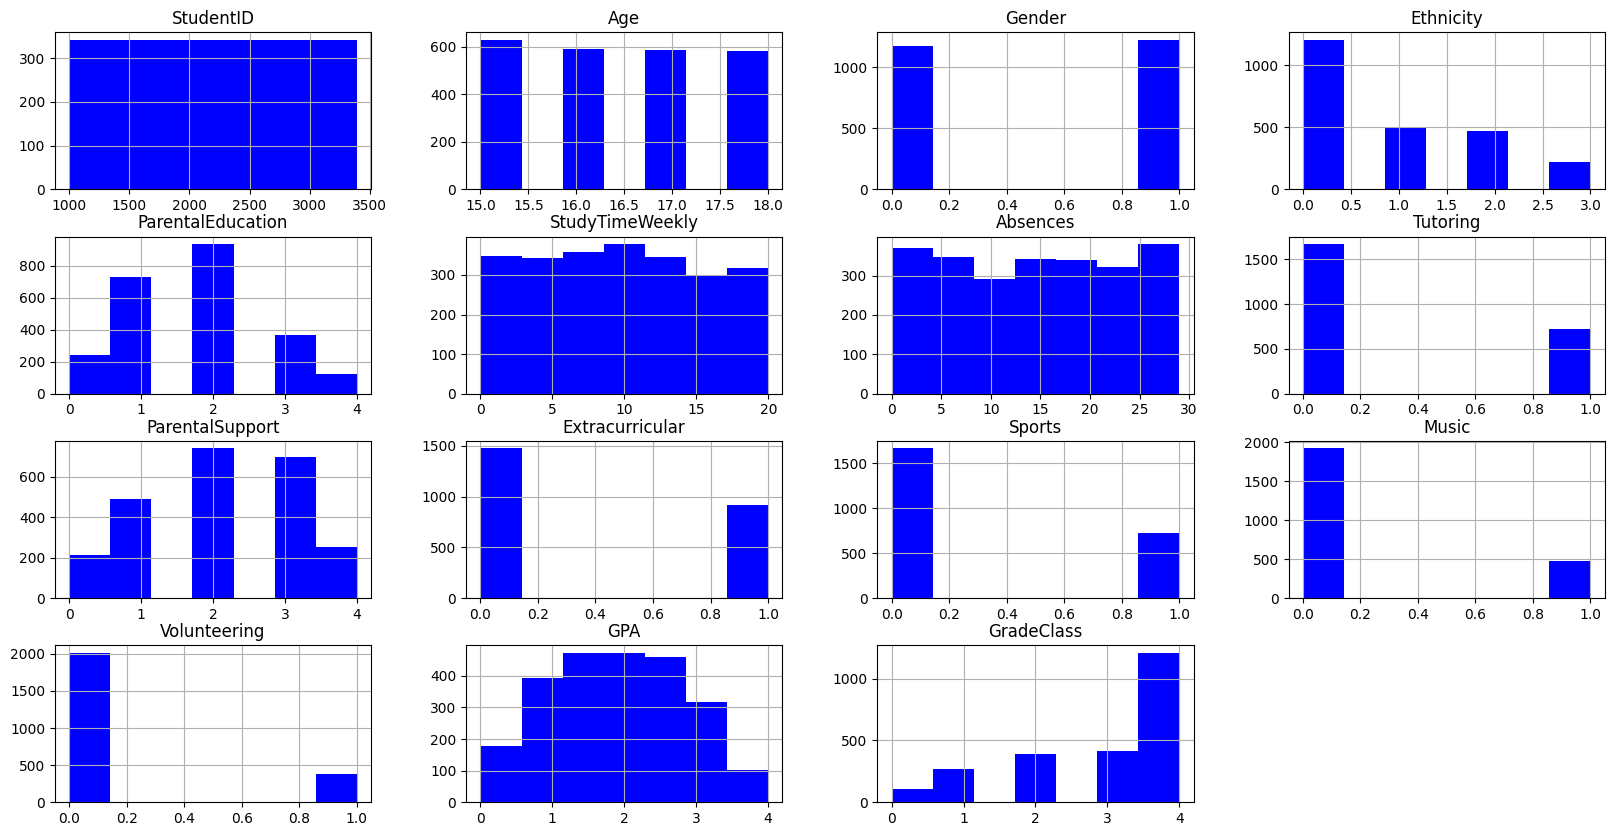

In [11]:
data.hist(figsize=(20,10),bins=7, color='blue')

Looking at the histograms above I can make some quick inferences:
* StudentID has no distribution and logically would have no effect on Grade
* There are only 4 ages in this dataset, which strangely makes age a categorical feature
* There are only 4 ethnicity variables in this dataset
* There are a lot of low-scoring students in this dataset (a majority of 4s - Fs in GradeClass)

## Define Categorical and Numerical Features

In order to proceed with assessing feature importance, there are two important steps:
1. Determine which columns are numeric and which are categoric
2. Encode the categoric columns to turn object variables into numbers
3. Scale numerical columns to ensure that large numbers have an equal effect on our model as small numbers

In [12]:
# Distinction is based on the number of different values in the column
columns = list(data.columns)

categoric_columns = []
numeric_columns = []

for i in columns:
    if len(data[i].unique()) > 5:
        numeric_columns.append(i)
    else:
        categoric_columns.append(i)
        
# Assuming the first column is an ID or non-numeric feature
numeric_columns = numeric_columns[1:]

print('Numerical features: ', numeric_columns)
print('Categorical features: ', categoric_columns)

Numerical features:  ['StudyTimeWeekly', 'Absences', 'GPA']
Categorical features:  ['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GradeClass']


I create an empty list for categoric columns and numeric columns, and then createa  for loop that cycles through our features and checks the number of unique values. If there are more than 5 unique values, we can assume that the feature is numerical. If there are less than 5, we can assume it's categorical. 

This isn't true in all instances, and we can see one thing here that is a little wierd: *Age is considered to be a categorical feature in this dataset.* 

The reason is that this dataset only contains high school students, so the age range is very small. If we were analyzing a dataset of students of all ages, then age would almost certainly be a numerical variable.

To ensure our numeric columns only contain numbers, I also convert the numeric columns to float64 type.

In [13]:
## Convert numeric columns to float64
data[numeric_columns] = data[numeric_columns].astype('float64')

## Encode Categorical Features and Scale Numerical Features

In [14]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

StandardScaler is used to standardize numerical features by transforming them to a common scale with mean 0 and standard deviation 1.

LabelEncoder is used to convert categorical labels into numerical values so that machine learning algorithms can process them.

In [15]:
 # Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode categorical features
data = data.copy()
for column in data[categoric_columns]:  
    data[column] = label_encoder.fit_transform(data[column])

# Standardize numerical features
scaler = StandardScaler()
data[numeric_columns] = scaler.fit_transform(data[numeric_columns])

## heat map 

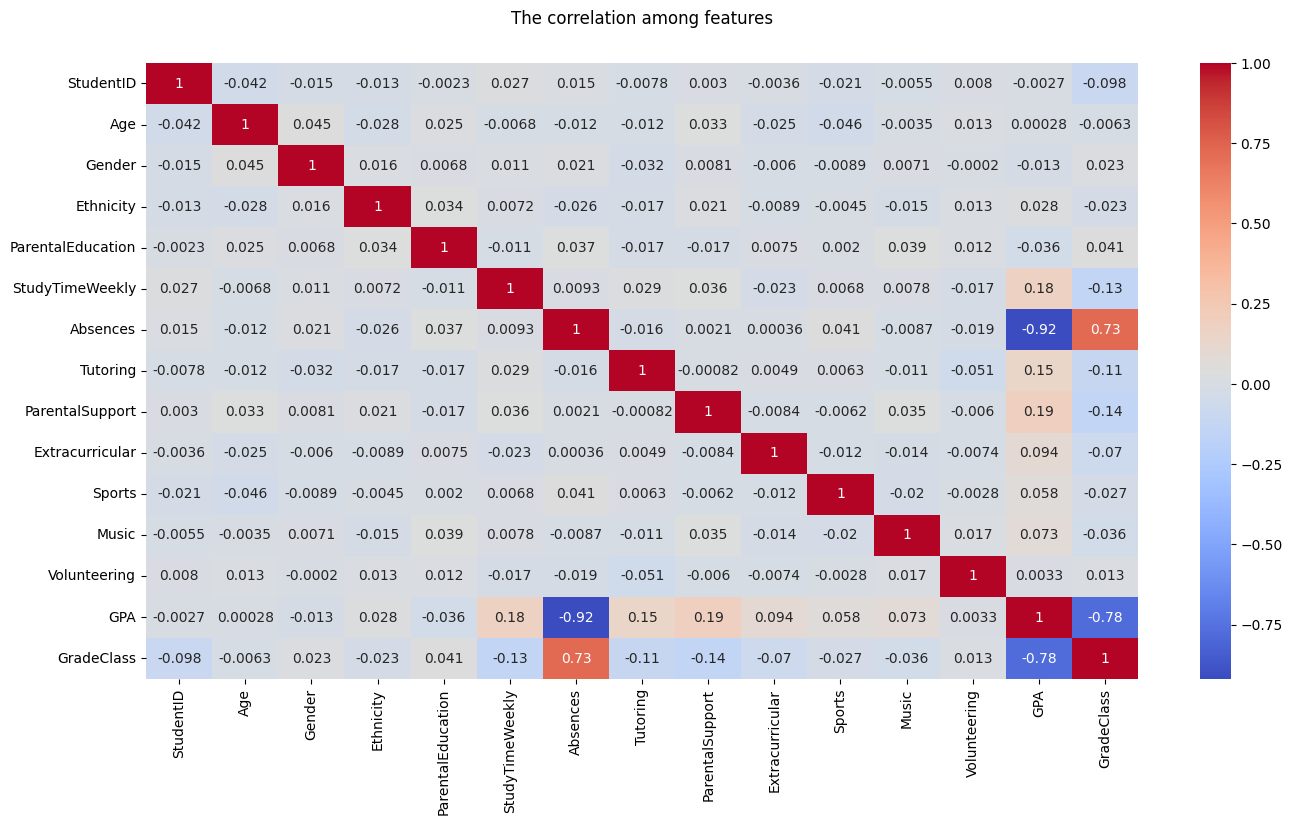

In [16]:
plt.figure(figsize=(16, 8))
sns.heatmap(data.corr(), annot = True, cmap = "coolwarm")
plt.title('The correlation among features',y= 1.05)
plt.show()

heat map is used to provide the corelaton among the feactures 

## countplot 

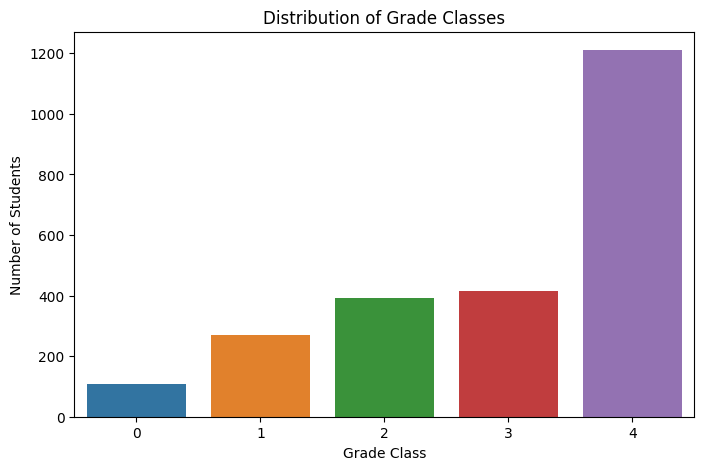

In [17]:
plt.figure(figsize=(8, 5))

sns.countplot(x='GradeClass', data=data)

plt.title('Distribution of Grade Classes')
plt.xlabel('Grade Class')
plt.ylabel('Number of Students')
plt.show()

A count plot shows how many students belong to each category.

For your target GradeClass

<h3 id='1' style="padding:20px; 
            color:#000000;
            margin:10px;
            font-size:220%;
            text-align:center;
            display:fill;
            border-radius:20px;
            border-width: 5px;
            border-style: solid;
            border-color:#000000;
            background-color:#B6DE8D;
            overflow:hidden;
            font-weight:500">📋 Train and Test </h3>

## Split the Dataset

In [35]:
x = data.drop(columns=['GradeClass', 'GPA', 'StudentID', 'Age'])
y = data['GradeClass']

# Splitting the data into training and testing sets (e.g., 80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

X → input features used to make predictions
y → target/output that we want to predict

Note: I'm also dropping some features that I don't want to add noise to the model here:
* GradeClass <- our target feature
* StudentID <- studentID is not logically a useful predictor of a student's grade
* Age <- I thought about this for a while, and I do not believe age should be used as a predictor for this data. The feature would not generalize well to future predictions on unseen data unless the age range is the same (15-18). I believe that removing age as a predictor creates a more robust model that we can apply to future student performance analysis in any academic setting (i.e. elementary school or university).
* GPA <- this would add unnecessary noise to the model and is not logical for future predictions

**For more information on why you should not use GPA as a predictor please see: [🚫Why You Shouldn't Use GPA to Predict Class Grade❌](https://www.kaggle.com/datasets/rabieelkharoua/students-performance-dataset/discussion/512561)**

In [19]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 25)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((1913, 11), (479, 11), (1913,), (479,))

## standard scaler

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_fit = scaler.fit_transform(x_train)
x_test_fit = scaler.transform(x_test)

StandardScaler is used to standardize numerical features by transforming them to a common scale with mean 0 and standard deviation 1.

## check the data

In [21]:
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (1913, 11)
x_test shape: (479, 11)
y_train shape: (1913,)
y_test shape: (479,)


<h3 id='1' style="padding:20px; 
            color:#000000;
            margin:10px;
            font-size:220%;
            text-align:center;
            display:fill;
            border-radius:20px;
            border-width: 5px;
            border-style: solid;
            border-color:#000000;
            background-color:#B6DE8D;
            overflow:hidden;
            font-weight:500">📋 Classification models</h3>

In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import RepeatedStratifiedKFold, RandomizedSearchCV, GridSearchCV, train_test_split
from scipy.stats import loguniform

# Silence Warnings (optional)
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## logistic regression

In [23]:
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(x_train_fit, y_train)
lr_acc = round(accuracy_score(y_test, model_lr.predict(x_test_fit)), 2)
print(f"Logistic Regression model accuracy :: {lr_acc * 100}%")

Logistic Regression model accuracy :: 72.0%


Logistic Regression is a supervised machine learning classification algorithm used to predict the class of a target variable. It calculates the probability of an observation belonging to different classes and assigns the class with the highest probability.

In this project, Logistic Regression is used to predict the student's GradeClass based on the available student performance features.

## decision tree

In [24]:
model_dt = DecisionTreeClassifier( random_state=101)
model_dt.fit(x_train_fit, y_train)
dt_acc = round( accuracy_score(y_test, model_dt.predict(x_test_fit)), 2)
print(f"Decision Tree model accuracy :: {dt_acc * 100}%")

Decision Tree model accuracy :: 63.0%


A Decision Tree is a supervised machine learning algorithm that makes decisions using a tree-like structure. It divides the dataset into smaller groups based on feature conditions until it reaches a final class prediction.

In this project, the Decision Tree predicts the student's GradeClass using student-related features.

## random forest

In [25]:
model_rf = RandomForestClassifier(n_estimators=100,random_state=101)
model_rf.fit(x_train_fit, y_train)
rf_acc = round(accuracy_score(y_test, model_rf.predict(x_test_fit)),2)
print(f"Random Forest model accuracy :: {rf_acc * 100}%")



Random Forest model accuracy :: 71.0%


Random Forest is an ensemble machine learning algorithm that combines multiple decision trees. Each tree makes a prediction, and the final prediction is obtained from the combined results of the trees.

It generally provides better stability than using a single decision tree.

## gradient boosting

In [26]:
model_gb = GradientBoostingClassifier(random_state=101)
model_gb.fit(x_train_fit, y_train)
gb_acc = round(accuracy_score(y_test, model_gb.predict(x_test_fit)),2)
print(f"Gradient Boosting model accuracy :: {gb_acc * 100}%")


Gradient Boosting model accuracy :: 71.0%


Gradient Boosting is an ensemble learning algorithm that builds multiple weak models sequentially. Each new model tries to reduce the errors made by the previous models.

It combines the predictions of these models to produce the final classification

## ADA boost

In [27]:
model_ab = AdaBoostClassifier( random_state=101)
model_ab.fit(x_train_fit, y_train)
ab_acc = round(accuracy_score(y_test, model_ab.predict(x_test_fit)),2)
print(f"AdaBoost model accuracy :: {ab_acc * 100}%")

AdaBoost model accuracy :: 68.0%


AdaBoost, or Adaptive Boosting, is an ensemble learning algorithm. It combines several weak learners to create a stronger classifier.

It gives more attention to incorrectly classified observations during the training process so that later learners can focus on difficult cases.

### KNN

In [28]:
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(x_train_fit, y_train)
knn_acc = round(accuracy_score(y_test, model_knn.predict(x_test_fit)),2)
print(f"KNN model accuracy :: {knn_acc * 100}%")

KNN model accuracy :: 56.99999999999999%


K-Nearest Neighbors (KNN) is a supervised classification algorithm that predicts the class of a new observation by looking at the classes of its nearest neighboring observations.

The value of K represents the number of neighboring data points considered for prediction.

## SVM

In [29]:
model_svm = SVC(kernel='rbf', random_state=101)
model_svm.fit(x_train_fit, y_train)
svm_acc = round(accuracy_score(y_test, model_svm.predict(x_test_fit)),2)
print(f"SVM model accuracy :: {svm_acc * 100}%")


SVM model accuracy :: 68.0%


Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification. It tries to find a decision boundary that separates different classes.

SVM can also use kernel functions to handle complex relationships between features.

## SGD classifier

In [30]:
from sklearn.linear_model import SGDClassifier
model_sgd = SGDClassifier(random_state=101,max_iter=1000)
model_sgd.fit(x_train_fit, y_train)
sgd_acc = round(accuracy_score(y_test, model_sgd.predict(x_test_fit)),2)
print(f"SGD Classifier model accuracy :: {sgd_acc * 100}%")




SGD Classifier model accuracy :: 66.0%


SGD Classifier stands for Stochastic Gradient Descent Classifier. It is a linear classification algorithm that uses stochastic gradient descent to optimize the model.

It is useful for large datasets because it can train efficiently using individual samples or small batches of samples.

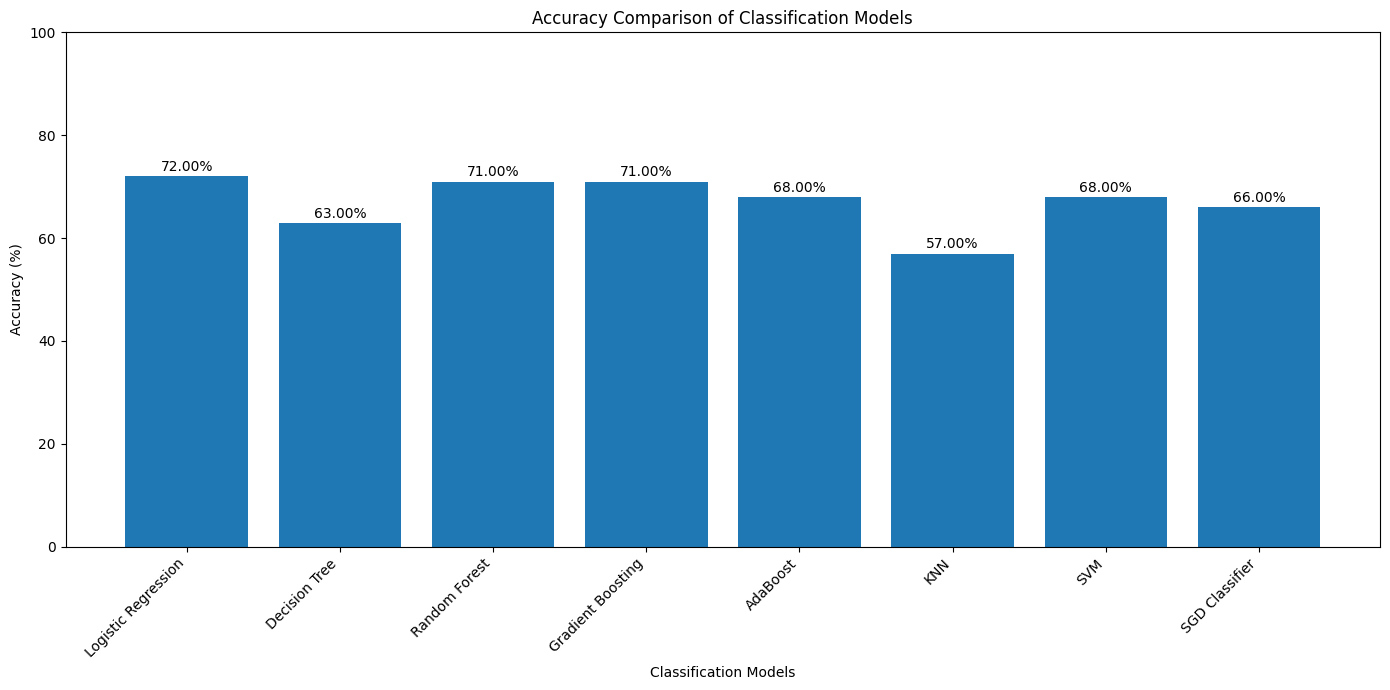

In [31]:
import matplotlib.pyplot as plt
models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting',
    'AdaBoost',
    'KNN',
    'SVM',
    'SGD Classifier'
]
accuracies = [
    lr_acc,
    dt_acc,
    rf_acc,
    gb_acc,
    ab_acc,
    knn_acc,
    svm_acc,
    sgd_acc
]

plt.figure(figsize=(14, 7))

bars = plt.bar(models, [x * 100 for x in accuracies])

plt.xlabel('Classification Models')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Comparison of Classification Models')

plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)

# Display accuracy on top of each bar
for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{acc * 100:.2f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

<h3 id='1' style="padding:20px; 
            color:#000000;
            margin:10px;
            font-size:220%;
            text-align:center;
            display:fill;
            border-radius:20px;
            border-width: 5px;
            border-style: solid;
            border-color:#000000;
            background-color:#B6DE8D;
            overflow:hidden;
            font-weight:500">📋 saving the Trained Model and scaler</h3>

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=101
)

model_rf.fit(x_train_fit, y_train)

rf_pred = model_rf.predict(x_test_fit)

rf_acc = round(
    accuracy_score(y_test, rf_pred),
    2
)

print(f"Random Forest model accuracy :: {rf_acc * 100}%")

Random Forest model accuracy :: 71.0%


In [33]:
import pickle

# Save Random Forest model
with open("model.pkl", "wb") as file:
    pickle.dump(model_rf, file)

# Save scaler
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Random Forest model and scaler saved successfully!")

Random Forest model and scaler saved successfully!


After training the Random Forest classifier, the trained model is saved using Python's pickle module. The StandardScaler used during preprocessing is also saved. Saving both allows us to reuse the same trained model and preprocessing steps during Streamlit deployment without training the model again.

model.pkl → stores the trained Random Forest model.
scaler.pkl → stores the fitted StandardScaler.
These files are later loaded in the Streamlit application for making predictions.

Your notebook section will look like

<a id="13"></a> 
<h2 style="background:linear-gradient(90deg,#6C5CE7,#8E7CFF); color:white; padding:15px 20px; border-radius:12px; border-left:8px solid #4834D4; font-family:Arial; text-align:center;"> 
✨ Thank You ✨
</h2>